In [1]:
import torch
import numpy as np
import pandas as pd
import soundfile as sf
from transformers import AutoModelForCTC, Wav2Vec2Processor
import json
from tqdm import tqdm
import os
from textgrid import TextGrid
import editdistance
from VAD_chunk import *

/home/imbenamor/miniconda3/envs/venv-test/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import unicodedata

REF_MAPPING = {
    # Consonants
    "Z": "ʒ",
    "A":"a",
    "S": "ʃ",
    "R": "ʁ",
    "r": "ʁ",
    "N": "ŋ",
    "J": "ɲ",
    "H": "ɥ",
    "g": "ɡ",
    "Z=": "ʒ",

    # Vowels
    "E": "ɛ",
    "O": "ɔ",
    "2": "ø",
    "9": "œ",
    "@": "ə",

    # Nasals (SAMPA)
    "a~": "ɑ̃",
    "o~": "ɔ̃",
    "e~": "ɛ̃",
    "9~": "ɛ̃",
    "E": "ɛ",
    "m=": "m",
    "n=": "n",
    "9~": "ɛ̃",
}
NASAL_CANONICAL = {

    "ã": "ɑ̃",
    "ẽ": "ɛ̃",
    "ĩ": "ɛ̃",
    "ỹ": "ɛ̃",
    "œ̃": "ɛ̃",
    "ə̃": "ɛ̃",
}
HYP_PROJECTION = {

    # Multilingual vowel variants
    "ɪ": "i",
    "ʊ": "u",
    "ɨ": "i",
    "ɜ": "ə",
    "ʌ": "ɔ",
    "ɒ": "ɔ",

    # Rhotic variants
    "ɣ": "ʁ",
    "ɹ": "ʁ",
    "ɾ": "ʁ",

    # Lateral variant
    "ʎ": "l",

    # Foreign consonants
    "β": "b",
    "θ": "t",
    "c": "k",
    "ɑ": "a",
    "mʲ":"m",
    "ɟ": "ɲ",
}
asr_to_ipa = {
    "aa": "a",        # a, ɑ
    "bb": "b",
    "kk": "k",        # c, k
    "dd": "d",
    "jj": "dʒ",       # also ʒ (see note below)
    "ei": "e",
    "ff": "f",
    "ii": "i",
    "yy": "j",
    "ll": "l",        # also ʎ
    "mm": "m",        # also mʲ
    "nn": "n",        # also ŋ
    "au": "o",
    "pp": "p",
    "ss": "s",        # also ts
    "tt": "t",
    "ch": "ʃ",        # also tʃ
    "ou": "u",
    "vv": "v",
    "ww": "w",
    "uu": "y",
    "zz": "z",
    "eu": "ø",
    "oe": "œ",
    "an": "ɑ̃",
    "oo": "ɔ",
    "on": "ɔ̃",
    "ee": "ə",
    "ai": "ɛ",
    "in": "ɛ̃",
    "un": "ɛ̃",       # second nasal mapping
    "gn": "ɲ",        # also ɟ depending on system
    "gg": "ɡ",
    "uy": "ɥ",
    "rr": "ʁ",
    "r": "ʁ",
    "SIL": "_"
}

import unicodedata



import re


def ipa_to_phoneme_list(text):
    """
    Convert IPA string into list of individual phoneme symbols.
    Keeps combining diacritics (like nasalization ̃) attached to base character.
    """
    
    # Remove spaces (word boundaries)
    text = text.replace(" ", "")
    
    phonemes = []
    current = ""
    
    for char in text:
        # If combining mark, attach to previous character
        if unicodedata.combining(char):
            current += char
        else:
            # Save previous phoneme
            if current:
                phonemes.append(current)
            current = char
    
    # Append last phoneme
    if current:
        phonemes.append(current)
    
    return phonemes



In [3]:
def build_inventory(token_lists):
    inventory = set()
    for tokens in token_lists:
        inventory.update(tokens)
    return sorted(inventory)


In [4]:
def get_reference_alignments_typaloc(textgrid_path, remove_silence=True):

    tg = textgrid.openTextgrid(
        textgrid_path,
        includeEmptyIntervals=True,
        duplicateNamesMode="rename"
    )

    # 🔎 Find tier containing "corr"
    tier_name = None
    for t in tg.tierNames:
        if "corr" in t.lower():
            tier_name = t
            break

    # fallback to first tier if none found
    if tier_name is None:
        tier_name = tg.tierNames[0]

    tier = tg.getTier(tier_name)

    ref_alignments = []

    for start, end, label in tier.entries:

        label = label.strip()

        # Skip empty intervals
        if not label:
            continue

        # Remove silence if requested
        if remove_silence and label.lower() in {"sil", "sp", "spn"}:
            continue

        ref_alignments.append({
            "phoneme": label,
            "start": start,
            "end": end
        })

    return ref_alignments

In [5]:
def get_reference_alignments(textgrid_path,t=""):

    tg = TextGrid()
    tg.read(textgrid_path)

    ref_alignments = []

    # assuming tier name is "phones"
    tier = tg.getFirst(t)
    for interval in tier.intervals:

        phoneme = interval.mark.strip()

        if phoneme == "" or phoneme in ["sil", "sp", "spn"]:
            continue


        ref_alignments.append({
            "phoneme": phoneme,
            "start": interval.minTime,
            "end": interval.maxTime 
        })
    return ref_alignments

In [6]:
import Levenshtein

def align_sequences(ref, hyp):
    alignment = []
    ops = Levenshtein.editops(ref, hyp)

    ref_idx = hyp_idx = 0
    op_idx = 0

    while ref_idx < len(ref) or hyp_idx < len(hyp):

        if op_idx < len(ops):
            op_type, src_pos, dest_pos = ops[op_idx]

            if op_type == "delete" and src_pos == ref_idx:
                alignment.append((ref_idx, None))
                ref_idx += 1
                op_idx += 1
                continue

            elif op_type == "insert" and dest_pos == hyp_idx:
                alignment.append((None, hyp_idx))
                hyp_idx += 1
                op_idx += 1
                continue

            elif op_type == "replace" and \
                 src_pos == ref_idx and \
                 dest_pos == hyp_idx:
                alignment.append((ref_idx, hyp_idx))
                ref_idx += 1
                hyp_idx += 1
                op_idx += 1
                continue

        # equal case
        if ref_idx < len(ref) and hyp_idx < len(hyp):
            alignment.append((ref_idx, hyp_idx))
            ref_idx += 1
            hyp_idx += 1
        elif ref_idx < len(ref):
            alignment.append((ref_idx, None))
            ref_idx += 1
        elif hyp_idx < len(hyp):
            alignment.append((None, hyp_idx))
            hyp_idx += 1

    return alignment



import Levenshtein
import numpy as np
import unicodedata
import re

VOWELS = set("aeiouyɛøœɔɑɨɪʊʌɒɜəɛ")

import unicodedata
import re
foreign_phonemes = {
    'β','θ','ɹ','ɾ','ɣ','ʌ','ʊ','ɪ','ɨ','ɨ̃','ɜ','ɒ','õ','ũ'
}
def normalize_phoneme_typaloc(ph):
    if ph is None:
        return None
    # Unicode normalization
    ph = unicodedata.normalize("NFC", ph)
    # enlever contenu [[...]]
    ph = re.sub(r"\[\[.*?\]\]", "", ph)

    # enlever crochets restants mal formés
    ph = re.sub(r"\[\[|\]\]", "", ph)

    # enlever contenu entre parenthèses
    ph = re.sub(r"\(.*?\)", "", ph)

    # enlever NONCORR
    ph = re.sub(r"\bNONCORR\b", "", ph)

    # nettoyer espaces
    ph = re.sub(r"\s+", " ", ph).strip()
    
    
    # enlever espaces multiples
    ph = re.sub(r"\s+", " ", ph).strip()
    ph =re.sub(r"\n.*", "", ph, flags=re.DOTALL)
    ph = ph.replace("yu","uy")
    ph = ph.replace("nn+yy","nn")
    ph = ph.replace("ei\t\t","ei")
    if "NB sur tDeb" in ph:
        ph="ei"
    ph = ph.replace("#a","a")
    ph = ph.replace("kk+","k")
    ph = re.sub(r"\*.*?\*", "", ph)
    ph = re.sub(r"\[\s*pause\s*\]", "", ph)
    ph = re.sub(r"\b\w*pause\w*\b", "", ph)
    
    if ph in ["_", "sil", "spn", "%", "?", "??","0","#", "=","euh","#erreur#"]:
        return None

    # Remove standalone combining marks
    if ph and all(unicodedata.combining(c) for c in ph):
        return None
    # --- Reference mapping ---
    if ph in asr_to_ipa.keys():
        ph = asr_to_ipa[ph]
    ph = ph.replace("dʒ","ʒ")
    return ph
def normalize_phoneme(ph, is_hyp=False):

    if ph is None:
        return None

    # 🔥 Strip first
    ph = ph.replace(" ", "")
    ph = re.sub(r"@t", "ə", ph)
    ph = re.sub(r"\?", "", ph)
    ph = re.sub(r"\@", "ə", ph)
    ph = ph.replace("<p:>", "")
    # Unicode normalization
    ph = unicodedata.normalize("NFC", ph)

    # Remove silence / junk
    if ph in {"_"," ", "sil", "spn", "%", "?", "0", "=", "fe~", "Ra~", "sjo~", "~e"}:
        return None

    # Remove standalone combining marks
    if ph and all(unicodedata.combining(c) for c in ph):
        return None

    # Reference mapping
    if not is_hyp and ph in REF_MAPPING:
        ph = REF_MAPPING[ph]

    # Hyp projection
    if is_hyp and ph in HYP_PROJECTION:
        ph = HYP_PROJECTION[ph]

    # Collapse multiple nasal marks
    ph = re.sub(r"\u0303+", "\u0303", ph)

    # Prevent nasalized consonants
    if len(ph) > 1:
        base = ph[0]
        if base not in VOWELS:
            ph = base

    # Canonical nasal mapping
    if ph in NASAL_CANONICAL:
        ph = NASAL_CANONICAL[ph]

    # Remove suprasegmentals
    ph = ph.replace("ː", "")

    # 🔥 Remove foreign AFTER projection
    if ph in foreign_phonemes:
        return None

    if ph == "":
        return None

    return ph


def clean_alignment_dict(alignment_list,flag="",is_hyp=False):
    """
    Normalize phonemes and remove empty or deleted ones.
    Keeps timestamps aligned.
    """
    
    cleaned = []
    
    for item in alignment_list:
        phoneme = item["phoneme"]

        if flag=="typaloc":
            phoneme_norm = normalize_phoneme_typaloc(phoneme)
        else:
            phoneme_norm = normalize_phoneme(phoneme, is_hyp=is_hyp)
        
        # Remove empty phonemes after normalization
        if phoneme_norm == "" or phoneme_norm is None:
            continue
        
        cleaned.append({
            "phoneme": phoneme_norm,
            "start": item["start"],
            "end": item["end"]
        })
    
    return cleaned



def confusion_matrix_from_alignment(ref, hyp, alignment):
    counts = defaultdict(lambda: defaultdict(int))

    for r_idx, h_idx in alignment:
        r = ref[r_idx] if r_idx is not None else "<DEL>"
        h = hyp[h_idx] if h_idx is not None else "<INS>"
        counts[r][h] += 1

    return pd.DataFrame(counts).fillna(0).astype(int)


def match_alignments_lev(ref_alignments, hyp_alignments,ref_seq,hyp_seq):

    alignment = align_sequences(ref_seq, hyp_seq)
    #cm = confusion_matrix_from_alignment(ref_seq, hyp_seq, alignment)
    start_errors = []
    end_errors = []
    duration_errors = []

    for ref_idx, hyp_idx in alignment:

        if ref_idx is None or hyp_idx is None:
            continue

        if ref_seq[ref_idx] == hyp_seq[hyp_idx]:

            r_start = ref_alignments[ref_idx]["start"]
            r_end   = ref_alignments[ref_idx]["end"]

            h_start = hyp_alignments[hyp_idx]["start"]
            h_end   = hyp_alignments[hyp_idx]["end"]

            start_errors.append(abs(r_start - h_start))
            end_errors.append(abs(r_end - h_end))
            duration_errors.append(
                abs((r_end - r_start) - (h_end - h_start))
            )

    return start_errors, end_errors, duration_errors

import librosa

def get_phoneme_alignments(model, processor, audio_path):
    audio, sr = sf.read(audio_path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    wav = torch.from_numpy(audio)
    chunks = vad_chunk_with_timestamps(wav)
    device = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments = []
    full_phoneme_parts = []

    for chunk in chunks:
        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)
        chunk_tensor = wav[start_sample:end_sample]

        inputs = processor(
            chunk_tensor.numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        predicted_ids = torch.argmax(logits, dim=-1)[0]
        
        decoded = processor.batch_decode(predicted_ids.unsqueeze(0))[0]
        full_phoneme_parts.append(decoded.strip())

        num_frames     = logits.shape[1]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        # ✅ Reset per chunk
        prev_id = None
        current_alignment = None

        for frame_idx, token_id in enumerate(predicted_ids.tolist()):
    
            if token_id == blank_id:
                prev_id = token_id
                continue
            
            phoneme = processor.decode([token_id])
            
            # Skip empty / space / word separator
            if phoneme in ["", " ", "|"]:
                prev_id = token_id
                continue
            
            # If this is a combining mark → attach to previous phoneme
            if unicodedata.combining(phoneme):
                if current_alignment is not None:
                    current_alignment["phoneme"] += phoneme
                prev_id = token_id
                continue
            
            if token_id != prev_id:
                if current_alignment is not None:
                    current_alignment["end"] = (
                        start_sample / 16000 + frame_idx * frame_duration
                    )
            
                start_time = start_sample / 16000 + frame_idx * frame_duration
                current_alignment = {
                    "phoneme": phoneme,
                    "start": start_time,
                    "end": None
                }
                all_alignments.append(current_alignment)
            
            prev_id = token_id


        # close last phoneme of this chunk using frame-based end
        if current_alignment is not None and current_alignment["end"] is None:
            current_alignment["end"] = (
                start_sample / 16000 + num_frames * frame_duration
            )
    full_phoneme_string = " ".join(full_phoneme_parts)
    return full_phoneme_string.strip(), all_alignments


In [7]:
import unicodedata
import torch
import numpy as np
import librosa
import soundfile as sf


def get_phoneme_alignments_wavlm(model, processor, audio_path):

    audio, sr = sf.read(audio_path)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    wav = torch.from_numpy(audio)

    chunks = vad_chunk_with_timestamps(wav)

    device = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments = []
    full_phoneme_parts = []

    for chunk in chunks:

        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)

        chunk_tensor = wav[start_sample:end_sample]

        inputs = processor(
            chunk_tensor.numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        predicted_ids = torch.argmax(logits, dim=-1)[0]

        decoded = processor.batch_decode(
            predicted_ids.unsqueeze(0)
        )[0]


        full_phoneme_parts.append(decoded.strip())

        num_frames     = logits.shape[1]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        prev_id = None
        current_alignment = None

        for frame_idx, token_id in enumerate(predicted_ids.tolist()):

            if token_id == blank_id:
                prev_id = token_id
                continue

            phoneme = processor.decode([token_id])

            # Skip empty / spaces / word separator
            if not phoneme or phoneme in [" ", "|"]:
                prev_id = token_id
                continue

            # If token changed → start new phoneme (CTC collapse)
            if token_id != prev_id:

                # close previous phoneme
                if current_alignment is not None:
                    current_alignment["end"] = (
                        start_sample / 16000
                        + frame_idx * frame_duration
                    )

                start_time = (
                    start_sample / 16000
                    + frame_idx * frame_duration
                )

                current_alignment = {
                    "phoneme": phoneme,
                    "start": start_time,
                    "end": None
                }

                all_alignments.append(current_alignment)

            else:
                # Same token → extend duration
                pass

            prev_id = token_id

        # close last phoneme in chunk
        if current_alignment is not None and current_alignment["end"] is None:
            current_alignment["end"] = (
                start_sample / 16000
                + num_frames * frame_duration
            )

    full_phoneme_string = " ".join(full_phoneme_parts)

    return full_phoneme_string.strip(), all_alignments

In [8]:
import torch
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import librosa
import unicodedata


def get_phoneme_alignments_viterbi(model, processor, audio_path):
    audio, sr = sf.read(audio_path)

    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    wav = torch.from_numpy(audio)

    chunks = vad_chunk_with_timestamps(wav)

    device = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments = []
    full_phoneme_parts = []

    for chunk in chunks:
        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)

        chunk_tensor = wav[start_sample:end_sample]

        inputs = processor(
            chunk_tensor.numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits  # (1, T, V)

        # Step 1 — Log softmax
        log_probs = F.log_softmax(logits, dim=-1)
        log_probs = log_probs.squeeze(0)  # (T, V)

        # step 2 — Greedy decoding to get phoneme sequence
        greedy_ids = torch.argmax(logits, dim=-1)[0]
        decoded = processor.batch_decode(greedy_ids.unsqueeze(0))[0].strip()
        full_phoneme_parts.append(decoded)

        # step 3 — Encode collapsed sequence
        target_ids = processor.tokenizer(decoded).input_ids
        target = torch.tensor(target_ids, device=device)

        # Step 4 — Viterbi forced alignment
        alignment = torchaudio.functional.forced_align(
            log_probs,
            target,
            blank=blank_id
        )

        alignment = alignment.tolist()

        # Step 5 — Convert frames to timestamps
        num_frames     = log_probs.shape[0]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        prev_id = None
        current_alignment = None

        for frame_idx, token_id in enumerate(alignment):

            if token_id == blank_id:
                prev_id = token_id
                continue

            phoneme = processor.decode([token_id])

            if phoneme in ["", " ", "|"]:
                prev_id = token_id
                continue

            if unicodedata.combining(phoneme):
                if current_alignment is not None:
                    current_alignment["phoneme"] += phoneme
                prev_id = token_id
                continue

            if token_id != prev_id:
                if current_alignment is not None:
                    current_alignment["end"] = (
                        start_sample / 16000 + frame_idx * frame_duration
                    )

                start_time = start_sample / 16000 + frame_idx * frame_duration

                current_alignment = {
                    "phoneme": phoneme,
                    "start": start_time,
                    "end": None
                }

                all_alignments.append(current_alignment)

            prev_id = token_id

        # close last phoneme
        if current_alignment is not None and current_alignment["end"] is None:
            current_alignment["end"] = (
                start_sample / 16000 + num_frames * frame_duration
            )

    full_phoneme_string = " ".join(full_phoneme_parts)

    return full_phoneme_string.strip(), all_alignments

In [2]:
MODEL_ID = "/vol/experiments3/imbenamor/TAPAS-FRAIS/models/wav2vec2-french-phonemizer"
#MODEL_ID = "/vol/experiments3/imbenamor/TAPAS-FRAIS/models/wavlm_finetuned_big/checkpoint-11000"

model = AutoModelForCTC.from_pretrained(MODEL_ID)
processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)

device = "cpu"
model = model.to(device)
model.eval()


/home/imbenamor/miniconda3/envs/venv-test/lib/python3.8/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/imbenamor/miniconda3/envs/venv-test/lib/python3.8/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Pl

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

In [3]:
print(processor.tokenizer.get_vocab())

{'1': 1, 'a': 2, 'b': 3, 'd': 4, 'e': 5, 'f': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'v': 20, 'w': 21, 'x': 22, 'y': 23, 'z': 24, 'ç': 25, 'ð': 26, 'ø': 27, 'ŋ': 28, 'œ': 29, 'ɐ': 30, 'ɑ': 31, 'ɒ': 32, 'ɔ': 33, 'ə': 34, 'ɛ': 35, 'ɜ': 36, 'ɡ': 37, 'ɣ': 38, 'ɨ': 39, 'ɪ': 40, 'ɬ': 41, 'ɲ': 42, 'ɹ': 43, 'ɾ': 44, 'ʁ': 45, 'ʃ': 46, 'ʊ': 47, 'ʌ': 48, 'ʍ': 49, 'ʒ': 50, 'ʔ': 51, 'ʲ': 52, 'ː': 53, '̃': 54, 'β': 55, 'θ': 56, '|': 0, '[UNK]': 57, '[PAD]': 58, '<s>': 59, '</s>': 60}


In [10]:
def extract_phoneme_sequence(alignment_list):
    return [item["phoneme"] for item in alignment_list]

In [40]:
"""from jiwer import process_words
from collections import defaultdict
style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
style_stats = defaultdict(lambda: {
    "S": 0,
    "D": 0,
    "I": 0,
    "N": 0,
    "boundary_errors": []
})
audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"
textgrid_dir = "/vol/corpora/Rhapsodie/TextGrids-fev2013/"

csv_path = "/vol/experiments3/imbenamor/TAPAS-FRAIS/data/rhap_phonemes_ref.csv"
style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")

df = pd.read_csv(csv_path)
df["file"]=[i.split("-")[0] for i in df["audio_filename"]]
df = pd.merge(df, style, on="file")


all_pairs = []
inventory=set()

total_edits = 0
total_ref_tokens = 0
all_boundary_errors=[]
total_S = total_D = total_I = total_N = 0
for _, row in tqdm(df.iterrows(), total=len(df)):
    f = "Rhap-"+row['file']+".wav"
    audio_path = os.path.join(audio_dir,f )
    if "D0001" not in audio_path and "M2006" not in audio_path and "D1003" not in audio_path:
        textgrid_path = os.path.join(textgrid_dir,f.replace(".wav", "-Pro.TextGrid"))
        pred_phonemes, pred_alignments = get_phoneme_alignments(model, processor, audio_path)
        ref_alignments = get_reference_alignments(textgrid_path,t="phone")
        
        
        clean_hyp = clean_alignment_dict(pred_alignments,is_hyp=True)
        clean_ref = clean_alignment_dict(ref_alignments,flag="",is_hyp=False)
        ref_offset = clean_ref[0]["start"]
        hyp_offset = clean_hyp[0]["start"]
        ref_intervals = [{
            "phoneme": item["phoneme"],
            "start": item["start"] - ref_offset,
            "end": item["end"] - ref_offset} for item in clean_ref]
    
        hyp_intervals = [{
            "phoneme": item["phoneme"],
            "start": item["start"] - hyp_offset,
            "end": item["end"] - hyp_offset} for item in clean_hyp]
        # Normalize
        ref_seq = extract_phoneme_sequence(clean_ref)
        hyp_seq = extract_phoneme_sequence(clean_hyp)
        all_pairs.append((ref_seq,hyp_seq))
        out = process_words(" ".join(ref_seq), " ".join(hyp_seq))
        style = row["style"]  # column already in your dataframe

        style_stats[style]["S"] += out.substitutions
        style_stats[style]["D"] += out.deletions
        style_stats[style]["I"] += out.insertions
        style_stats[style]["N"] += len(ref_seq)
        
        start_err, end_err, dur_err = match_alignments_lev(ref_intervals, hyp_intervals,ref_seq,hyp_seq)
    
        #all_boundary_errors.extend(start_err)
        style_stats[style]["boundary_errors"].extend(start_err)
    
        if len(start_err) > 0:
            print("Max file boundary error (sec):", max(start_err))
"""

  2%|█▌                                                                                  | 1/53 [00:18<15:52, 18.31s/it]

Max file boundary error (sec): 1.993678189941761


  4%|███▏                                                                                | 2/53 [00:23<09:09, 10.78s/it]

Max file boundary error (sec): 0.491528137651823


  6%|████▊                                                                               | 3/53 [00:36<09:33, 11.47s/it]

...

Max file boundary error (sec): 1.9247123754699231


 98%|█████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [09:53<00:06,  6.92s/it]

Max file boundary error (sec): 0.3969093108531414


100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [10:26<00:00, 11.83s/it]

Max file boundary error (sec): 0.9957203068073


In [41]:
"""results = []

for style, stats in style_stats.items():
    S = stats["S"]
    D = stats["D"]
    I = stats["I"]
    N = stats["N"]

    per = (S + D + I) / N if N > 0 else 0

    errors = np.array(stats["boundary_errors"])

    if len(errors) > 0:
        mean_err = np.mean(errors)
        median_err = np.median(errors)
        max_err = np.max(errors)

        within_20ms = np.mean(errors <= 0.02) * 100
        within_50ms = np.mean(errors <= 0.05) * 100
    else:
        mean_err = median_err = max_err = 0
        within_20ms = within_50ms = 0

    results.append({
        "style": style,
        "PER": per*100,
        "Substitutions": S,
        "Deletions": D,
        "Insertions": I,
        "N_ref": N,
        "Mean_boundary_error": mean_err*1000,
        "Median_boundary_error": median_err*1000,
        "Max_boundary_error": max_err*1000,
        "%_within_20ms": within_20ms,
        "%_within_50ms": within_50ms
    })

results_df = pd.DataFrame(results)
results_df"""

,style,PER,Substitutions,Deletions,Insertions,N_ref,Mean_boundary_error,Median_boundary_error,Max_boundary_error,%_within_20ms,%_within_50ms
0,spont,20.394474,2831,5487,864,45022,204.642003,34.481190,53718.166421,33.347864,60.538361
1,planned,11.811589,1367,1675,411,29234,74.513103,42.260306,5535.465391,27.787111,55.200061
2,semi,21.126761,845,1892,368,14697,376.800394,131.657183,10292.263633,1.906355,10.209030


In [11]:
from jiwer import process_words
from collections import defaultdict
from pathlib import Path

audio_dir = "/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK"
textgrid_dir = Path("/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK")
ref_files = textgrid_dir.glob("*") 

ref_files

<generator object Path.glob at 0x7f7f640695f0>

In [15]:
from praatio import textgrid
ref_dict = {
    str(f.stem)[:-11]: str(f)
    for f in ref_files
    if str(f.stem).endswith("pr_analyse")
}
ref_dict

{'CCM-003733-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003733-01_L01_pr_analyse.TextGrid',
 'CCM-003148-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003148-01_L01_pr_analyse.TextGrid',
 'CCM-003848-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003848-01_L01_pr_analyse.TextGrid',
 'CCM-003734-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003734-01_L01_pr_analyse.TextGrid',
 'CCM-003346-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003346-01_L01_pr_analyse.TextGrid',
 'CCM-003557-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-003557-01_L01_pr_analyse.TextGrid',
 'CCM-001773-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees_ParisTypaloc-TapasFrais/8-PARK/CCM-001773-01_L01_pr_analyse.TextGrid',
 'CCM-003130-01_L01': '/vol/corpora/TAPAS_FRAIS/Data_partagees

In [18]:

#df["file"]=[i.split("-")[1].split(".")[0] for i in df["audio_filename"]]
#df = pd.merge(df, style, on="file")

all_pairs = []
ref_inventory=set()
pred_inventory=set()
i=0
total_edits = 0
total_ref_tokens = 0
all_boundary_errors=[]
total_S = total_D = total_I = total_N = 0
for f in ref_dict.keys():
    #others
    #filename = f.stem
    #rhapsodie
    #filename = f.stem
    audio_path = os.path.join(audio_dir, f+".wav")
    #rhapsodie
    #audio_path = os.path.join(audio_dir, filename[:-4]+".wav")
    #if "D0001" not in audio_path and "M2006" not in audio_path and "D1003" not in audio_path:
    i+=1
    #print(i)
    #textgrid_path = os.path.join(textgrid_dir,filename+".TextGrid")
    #textgrid_path = os.path.join(textgrid_dir,filename+".TextGrid")
    textgrid_path = ref_dict[f]
    pred_phonemes, pred_alignments = get_phoneme_alignments(model, processor, audio_path)
    #print(pred_alignments)
    #ref_alignments = get_reference_alignments(textgrid_path,"phone")
    #ref_alignments = get_reference_alignments(textgrid_path,"MAU")
    ref_alignments = get_reference_alignments_typaloc(textgrid_path)

    clean_hyp = clean_alignment_dict(pred_alignments,is_hyp=True)
    clean_ref = clean_alignment_dict(ref_alignments,flag="typaloc",is_hyp=False)

    ref_offset = clean_ref[0]["start"]
    hyp_offset = clean_hyp[0]["start"]
    
    ref_intervals = [{
        "phoneme": item["phoneme"],
        "start": item["start"] - ref_offset,
        "end": item["end"] - ref_offset} for item in clean_ref]
    #print(ref_intervals)
    hyp_intervals = [{
        "phoneme": item["phoneme"],
        "start": item["start"] - hyp_offset,
        "end": item["end"] - hyp_offset} for item in clean_hyp]
    # Normalize
    ref_seq = extract_phoneme_sequence(clean_ref)
    hyp_seq = extract_phoneme_sequence(clean_hyp)

    pred_inventory.update(hyp_seq)
    
    ref_inventory.update(ref_seq)
    print(ref_inventory - pred_inventory)
    print("--")
    print(pred_inventory - ref_inventory)
    all_pairs.append((ref_seq,hyp_seq))
    
    out = process_words(" ".join(ref_seq), " ".join(hyp_seq))
    total_S += out.substitutions
    total_D += out.deletions
    total_I += out.insertions
    total_N += len(ref_seq)
    
    start_err, end_err, dur_err = match_alignments_lev(ref_intervals, hyp_intervals,ref_seq,hyp_seq)

    all_boundary_errors.extend(start_err)

    if len(start_err) > 0:
        print("Max file boundary error (sec):", max(start_err))


{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 1.6566426180061953
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 0.291718124327474
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 1.0578166276986707
Maximum timestamp in Textgrid changed from (73.375125) to (73.38)
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 0.13576174784150652
Maximum timestamp in Textgrid changed from (63.158313) to (63.16)
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 0.5964687266388751
Maximum timestamp in Textgrid changed from (84.149187) to (84.15)
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 0.28651433409284266
Maximum timestamp in Textgrid changed from (51.827) to (51.83)
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 3.7999621363370757
{'ɥ'}
--
{'ə'}
Max file boundary error (sec): 1.028587759511371


In [19]:
len(all_pairs)

8

In [20]:
corpus_per =  (total_S + total_D + total_I) / total_N

if len(all_boundary_errors) > 0:
    #flat_errors = [e for sublist in all_boundary_errors for e in sublist]
    errors = np.array(all_boundary_errors)
    print("GLOBAL max error (sec):", np.max(errors))
    print("GLOBAL median error (sec):", np.median(errors))

    mean_boundary_error = np.mean(errors)
    median_boundary_error = np.median(errors)

    within_20ms = np.mean(errors <= 0.02) * 100
    within_50ms = np.mean(errors <= 0.05) * 100
else:
    mean_boundary_error = 0
    median_boundary_error = 0
    within_20ms = 0
    within_50ms = 0
print("\n===== FINAL RESULTS =====")
print(f"Corpus PER: {corpus_per * 100:.2f}%")
print(f"Mean boundary error: {mean_boundary_error * 1000:.2f} ms")
print(f"Median boundary error: {median_boundary_error * 1000:.2f} ms")
print(f"% within 20ms: {within_20ms:.2f}%")
print(f"% within 50ms: {within_50ms:.2f}%")


GLOBAL max error (sec): 3.7999621363370757
GLOBAL median error (sec): 0.0338040018252137

===== FINAL RESULTS =====
Corpus PER: 23.96%
Mean boundary error: 532.35 ms
Median boundary error: 33.80 ms
% within 20ms: 32.66%
% within 50ms: 62.44%


In [38]:
#=====================================
# create csv with ref, pred 
#===================================
import pandas as pd
import re
import unicodedata

def fix_combining(text):
    # remove space before combining marks
    text = re.sub(r"\s+([\u0300-\u036f])", r"\1", text)
    # normalize to composed form
    text = unicodedata.normalize("NFC", text)
    return text
hyp =[]
ref=[]
for i , j in all_pairs:
    hyp.append(j)
    ref.append(i)
files=[]
textgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013")
ref_files = textgrid_dir.glob("*") 

for f in ref_files:
    
    filename = f.stem
    audio_path = os.path.join(audio_dir, filename+".wav")
    if "D0001" not in audio_path and "M2006" not in audio_path and "D1003" not in audio_path:
        files.append(f)
data = []

for fname, r, pred in zip(files, ref, hyp):
    data.append({
        "filename": fname.stem.split(".")[0],
        "ref_phonemes": fix_combining(" ".join(r)),
        "pred_phonemes": fix_combining(" ".join(pred))
    })

df1 = pd.DataFrame(data)
df1.to_csv("/vol/experiments3/imbenamor/TAPAS-FRAIS/data/w2v_pred_rhap.csv")

In [39]:
df1

,filename,ref_phonemes,pred_phonemes
0,Rhap-D0020-Pro,o w i i j a p l ɛ̃ d o t ʁ i t i n e ʁ ɛ ʁ p ɔ...,w i p l ɛ̃ d o t ʁ i t i n e ʁ ɛ ʁ p ɔ s i b l...
1,Rhap-D2002-Pro,ʒ ə s ɥ i p a d y t y y n a ʃ a ʁ n e d ə d ə ...,ʒ ə s y i p a d t u n a ʃ a ʁ n e d ə b a t t ...
2,Rhap-M0009-Pro,a l ɔ ʁ l a t y v w a d ɔ̃ k t y k ɔ̃ t i n y ...,a l ɔ ʁ l a t y v w a d ɔ̃ t y k ɔ̃ t i n y t ...
3,Rhap-D0017-Pro,œ w i v u v u v u p ʁ ə n e a d ʁ w a t l a d ...,w i p ʁ ə n e a d ʁ w a l a d ʁ w a t e v u z ...
4,Rhap-D2006-Pro,l ə p ʁ ɔ ɡ ʁ a m m ə s j ø l ə p ʁ ə m j e m ...,m ə s j ø l ə p ʁ ə m j e m i n i s t ʁ k ɔ̃ p...
5,Rhap-M0002-Pro,d ɔ̃ k œ j a y n ø ʒ œ n f i j ə a b i j e t u...,k ɛ y n ʒ ø n f i j t u t ɑ̃ n w a ʁ k i ɑ̃ s ...
6,Rhap-D2009-Pro,o ʒ a k ɔ ʁ d y n p ɥ i s ɑ̃ s e n ɔ ʁ m a l a...,ʁ ɔ ʒ a k ɔ ʁ d y n p y i s ɑ̃ s e n ɔ ʁ m a l...
7,Rhap-M0023-Pro,a l ɔ ʁ œ i j a y n œ ʒ œ n f i j œ k i ɑ̃ d a...,a l ɔ ʁ i a y n ʒ ø n f i j k i ɑ̃ n d a b ɔ ʁ...
8,Rhap-D0005-Pro,e œ m e d ɔ̃ k œ v u z a v e ɛ ɡ z ɛ ʁ s e k w...,t ɑ̃ u s a v e w w i b a d ɔ b a d ə s ɛ̃ ʒ e ...
9,Rhap-M0016-Pro,œ b ɔ̃ p u ʁ a l e d y s e ɛ ʁ d e t e a l a ɡ...,p u ʁ a l e d y s ɛ ʁ d e p e a l a ɡ a ʁ d ə ...


In [9]:
"""import pandas as pd
import numpy as np

results = []

for style, stats in style_stats.items():
    S = stats["S"]
    D = stats["D"]
    I = stats["I"]
    N = stats["N"]

    per = (S + D + I) / N if N > 0 else 0

    errors = np.array(stats["boundary_errors"])

    if len(errors) > 0:
        mean_err = np.mean(errors)
        median_err = np.median(errors)
        max_err = np.max(errors)

        within_20ms = np.mean(errors <= 0.02) * 100
        within_50ms = np.mean(errors <= 0.05) * 100
    else:
        mean_err = median_err = max_err = 0
        within_20ms = within_50ms = 0

    results.append({
        "style": style,
        "PER": per*100,
        "Substitutions": S,
        "Deletions": D,
        "Insertions": I,
        "N_ref": N,
        "Mean_boundary_error": mean_err*1000,
        "Median_boundary_error": median_err*1000,
        "Max_boundary_error": max_err*1000,
        "%_within_20ms": within_20ms,
        "%_within_50ms": within_50ms
    })

results_df = pd.DataFrame(results)
results_df"""

'import pandas as pd\nimport numpy as np\n\nresults = []\n\nfor style, stats in style_stats.items():\n    S = stats["S"]\n    D = stats["D"]\n    I = stats["I"]\n    N = stats["N"]\n\n    per = (S + D + I) / N if N > 0 else 0\n\n    errors = np.array(stats["boundary_errors"])\n\n    if len(errors) > 0:\n        mean_err = np.mean(errors)\n        median_err = np.median(errors)\n        max_err = np.max(errors)\n\n        within_20ms = np.mean(errors <= 0.02) * 100\n        within_50ms = np.mean(errors <= 0.05) * 100\n    else:\n        mean_err = median_err = max_err = 0\n        within_20ms = within_50ms = 0\n\n    results.append({\n        "style": style,\n        "PER": per*100,\n        "Substitutions": S,\n        "Deletions": D,\n        "Insertions": I,\n        "N_ref": N,\n        "Mean_boundary_error": mean_err*1000,\n        "Median_boundary_error": median_err*1000,\n        "Max_boundary_error": max_err*1000,\n        "%_within_20ms": within_20ms,\n        "%_within_50ms": 

In [37]:
#results_df.to_csv("/vol/experiments3/imbenamor/TAPAS-FRAIS/data/results_w2v_ctc.csv")

In [37]:
inventory=set()
for i in ref:
    inventory.update(i)

inventory

{'a',
 'b',
 'd',
 'e',
 'f',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 's',
 't',
 'u',
 'v',
 'w',
 'y',
 'z',
 'ø',
 'ŋ',
 'œ',
 'ɑ̃',
 'ɔ',
 'ɔ̃',
 'ə',
 'ɛ',
 'ɛ̃',
 'ɡ',
 'ɥ',
 'ɲ',
 'ʁ',
 'ʃ',
 'ʒ'}

In [81]:
tmp = pd.read_csv("/vol/experiments3/imbenamor/TAPAS-FRAIS/data/w2v_pred_park.csv")

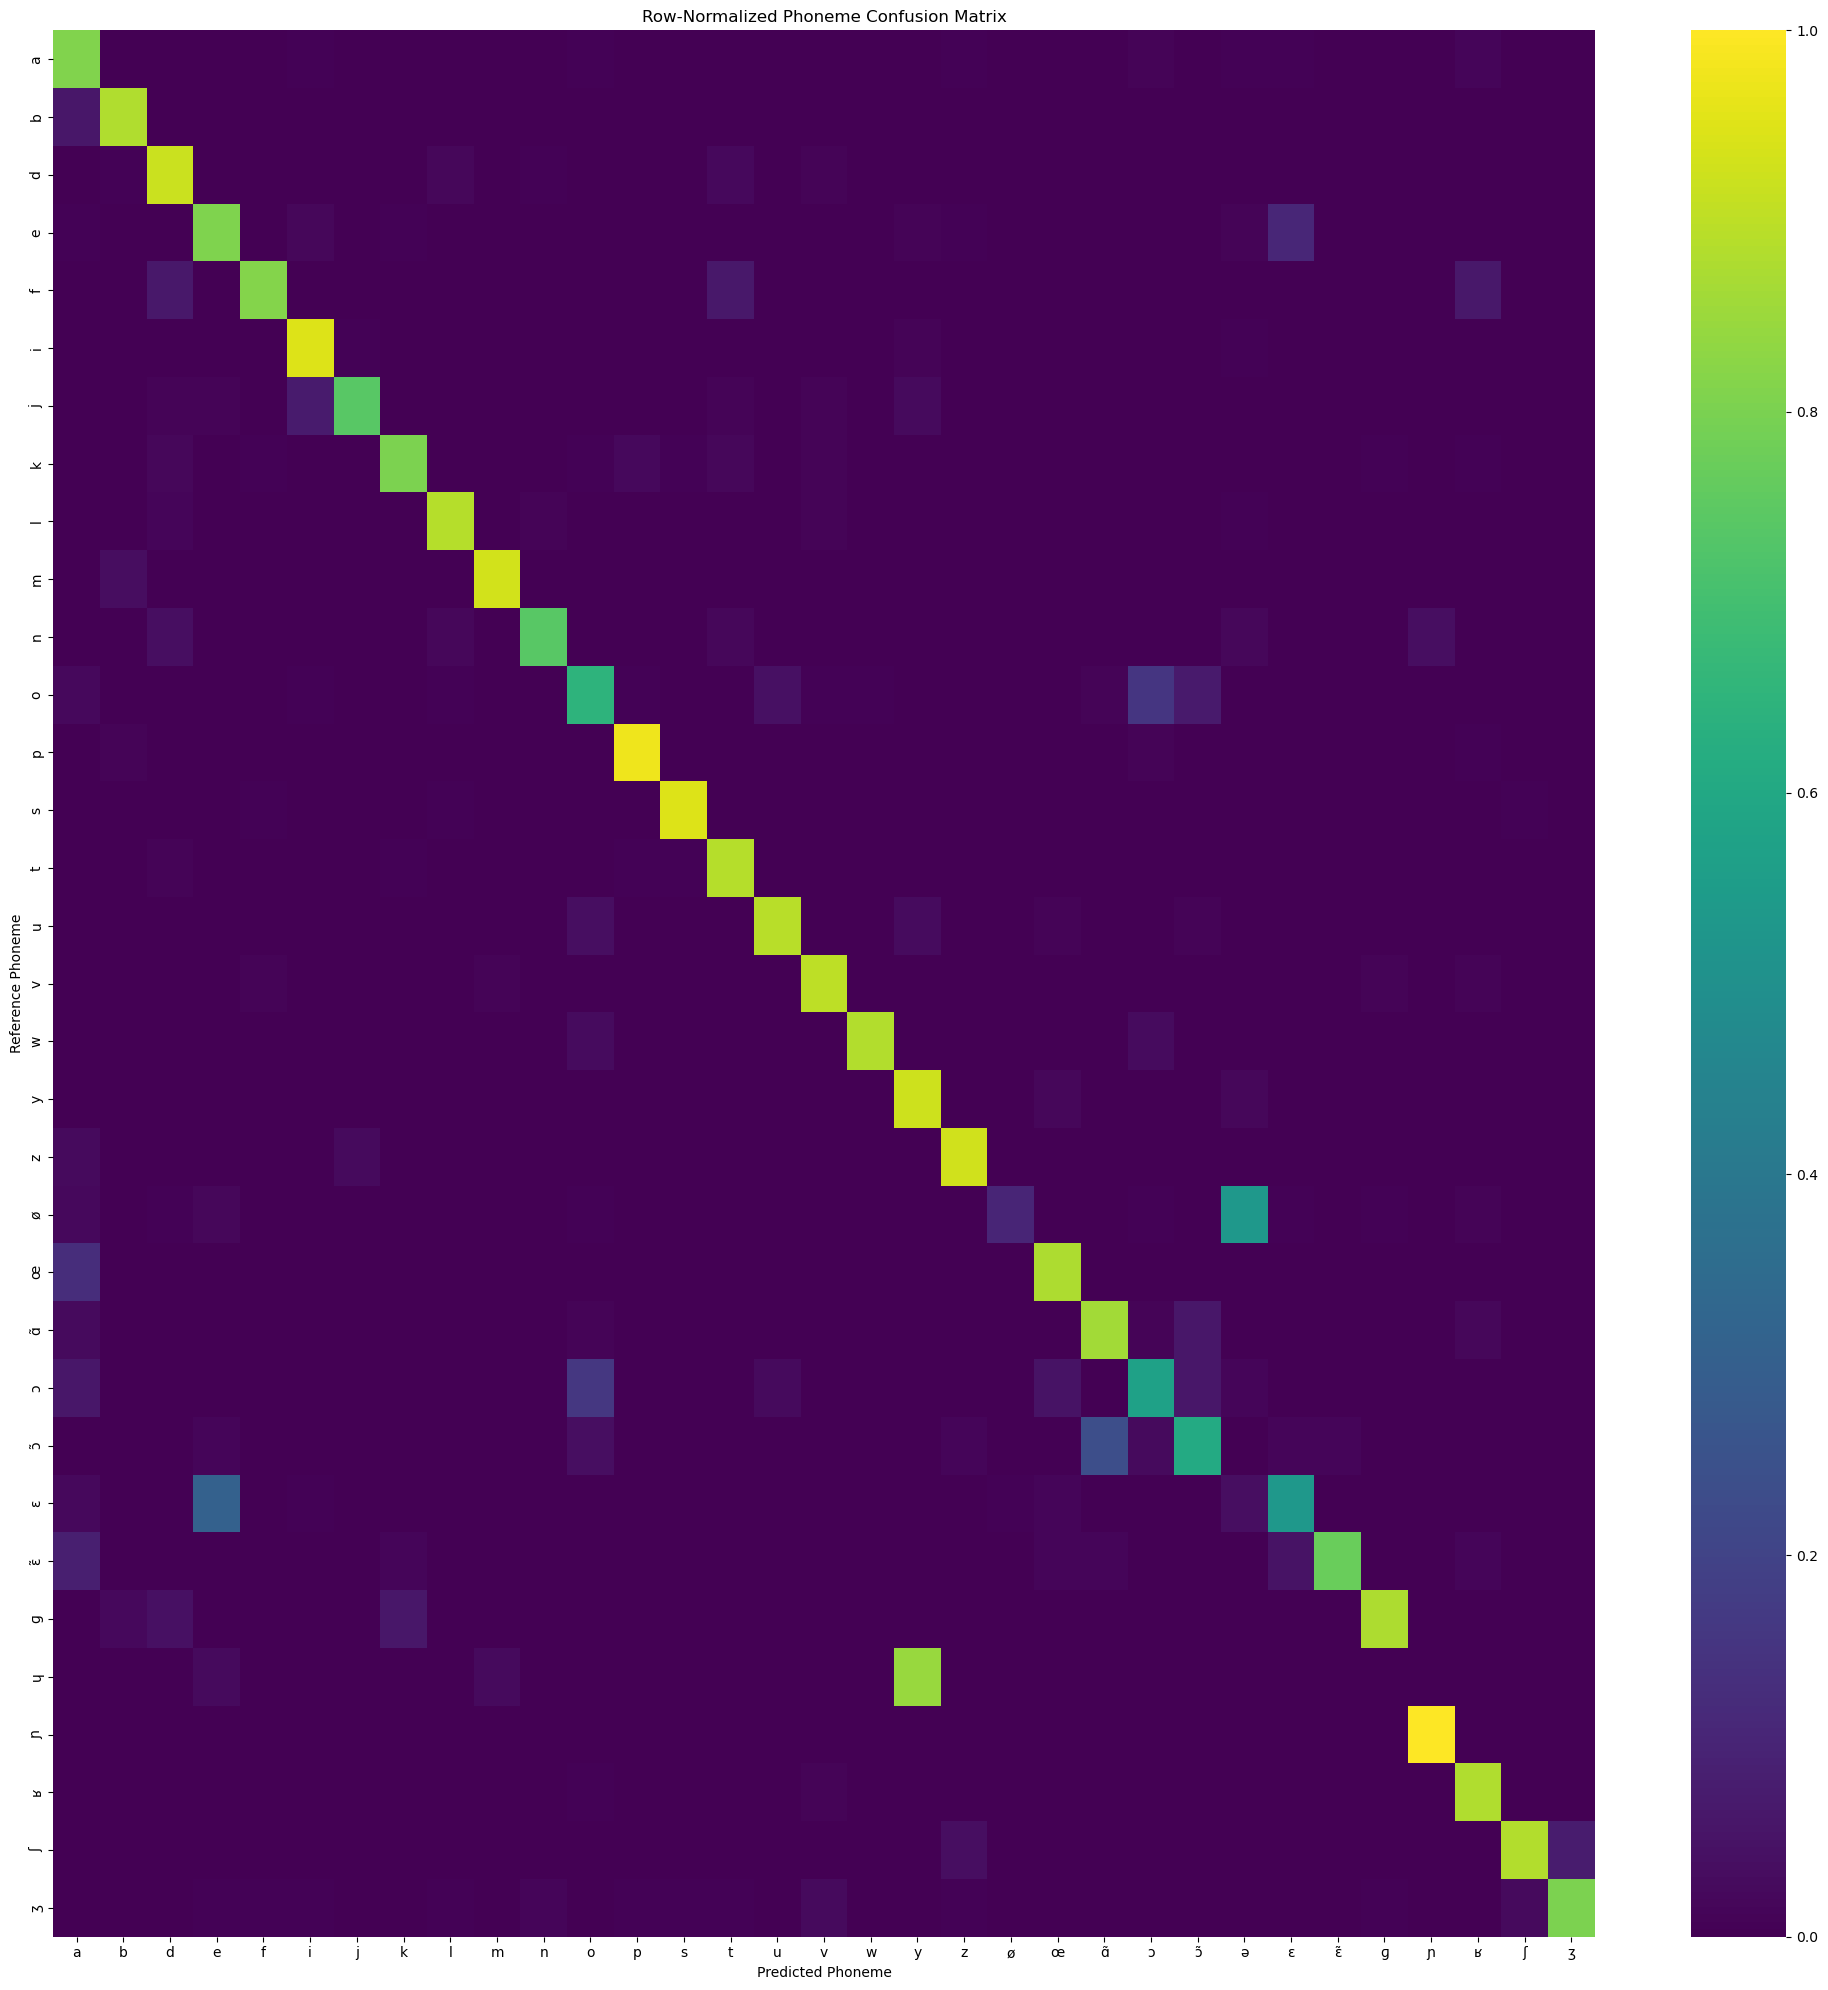

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
import numpy as np


# -------------------------------
# 1️⃣ Build Global Confusion Counts
# -------------------------------

global_counts = defaultdict(lambda: defaultdict(int))

for _,row in tmp[["ref_phonemes","pred_phonemes"]].iterrows():
    ref = list(row["ref_phonemes"].split())
    hyp = list(row["pred_phonemes"].split())
    alignment = align_sequences(ref, hyp)

    for r_idx, h_idx in alignment:
        r = ref[r_idx] if r_idx is not None else "<DEL>"
        h = hyp[h_idx] if h_idx is not None else "<INS>"
        global_counts[r][h] += 1


# -------------------------------
# 2️⃣ Create DataFrame (rows = reference)
# -------------------------------

confusion_df = pd.DataFrame.from_dict(
    global_counts,
    orient="index"
).fillna(0).astype(int)


# -------------------------------
# 3️⃣ Make Matrix Square
# -------------------------------

all_labels = sorted(
    set(confusion_df.index) | set(confusion_df.columns)
)

confusion_df = confusion_df.reindex(
    index=all_labels,
    columns=all_labels,
    fill_value=0
)


# -------------------------------
# 4️⃣ Row-Normalize (P(pred | ref))
# -------------------------------

confusion_norm = confusion_df.div(
    confusion_df.sum(axis=1).replace(0, 1),
    axis=0
)


# -------------------------------
# 5️⃣ Remove <DEL> and <INS>
# -------------------------------

confusion_clean = confusion_norm.drop(
    index=["<DEL>", "<INS>"], errors="ignore"
).drop(
    columns=["<DEL>", "<INS>"], errors="ignore"
)


# -------------------------------
# 6️⃣ Remove All-Zero Rows & Columns
# -------------------------------

confusion_clean = confusion_clean.loc[
    (confusion_clean != 0).any(axis=1),
    (confusion_clean != 0).any(axis=0)
]


# -------------------------------
# 7️⃣ Visualization (Correct Scale 0–1)
# -------------------------------

plt.figure(figsize=(20,20))
sns.heatmap(confusion_clean,
            cmap="viridis",
            vmin=0,
            vmax=1)

plt.xlabel("Predicted Phoneme")
plt.ylabel("Reference Phoneme")
plt.title("Row-Normalized Phoneme Confusion Matrix")
plt.tight_layout()

#plt.savefig("/vol/experiments3/imbenamor/TAPAS-FRAIS/figures/w2v_phonemes_confusion.png")

plt.show()




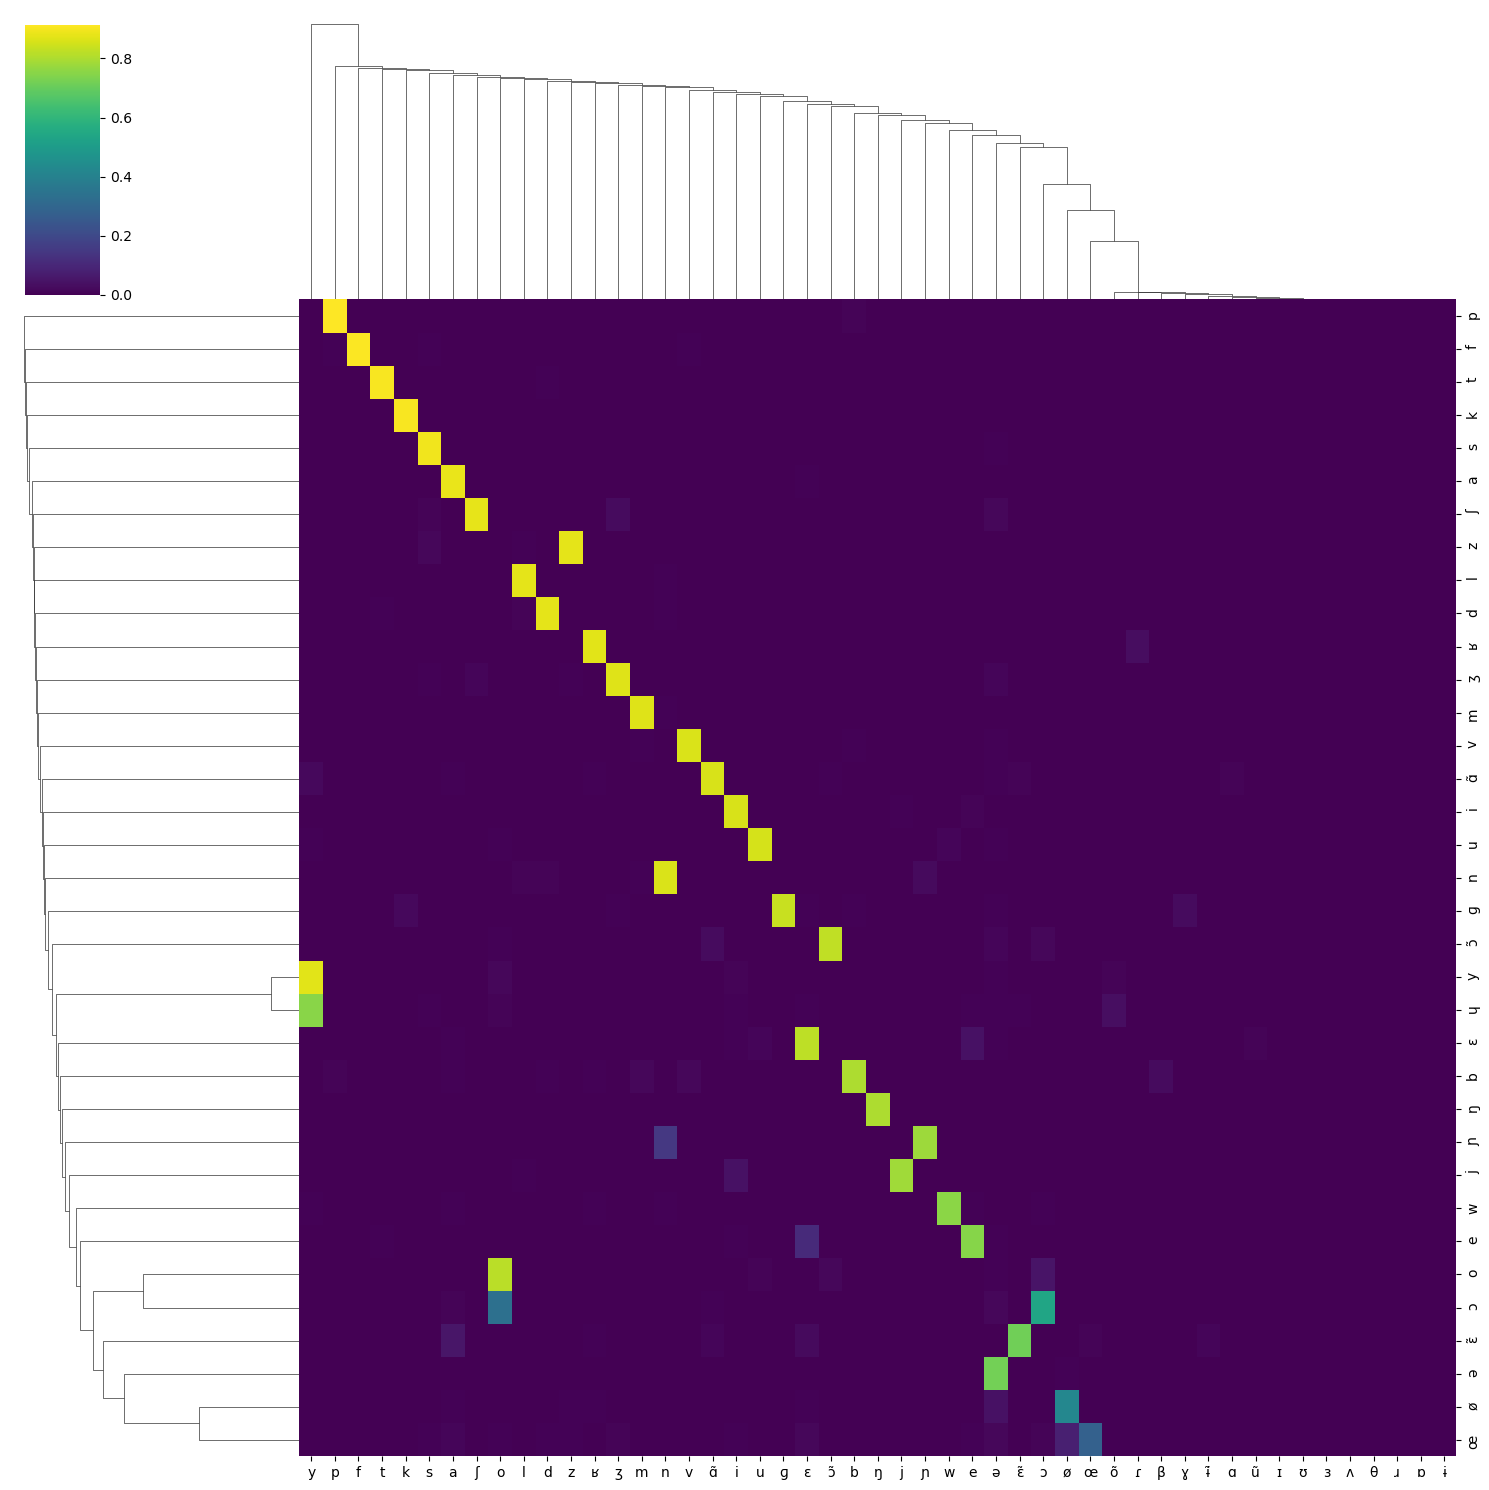

In [17]:
"""sns.clustermap(confusion_clean,
               metric="euclidean",
               method="average",
               cmap="viridis",
               figsize=(15,15))
plt.show()
""""

In [11]:
correct = confusion_df.values.diagonal().sum()
total = confusion_df.values.sum()

accuracy = correct / total
print("Accuracy:", accuracy)
print("PER approx:", 1 - accuracy)

NameError: name 'confusion_df' is not defined

In [20]:
corpus_per

0.18223718619246862

GLOBAL max error (sec): 6.073156565656561
GLOBAL median error (sec): 0.05171652587993769

===== FINAL RESULTS =====
Corpus PER: 18.22%
Mean boundary error: 285.95 ms
Median boundary error: 51.72 ms
% within 20ms: 21.36%
% within 50ms: 48.72%
